In [72]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

## Task 2

In [73]:
# full weighted graph (with symmetric weights)
n = 10
A = np.random.uniform(low=1, high=11, size=(n, n))

# symmetrization
P = ((A + A.T) / 2)

# normalization - dividing by column sums
P = P / P.sum(axis=0)
P

array([[0.07875445, 0.10402079, 0.14261423, 0.10968697, 0.04454692,
        0.09920587, 0.06400369, 0.16403212, 0.14482915, 0.10092778],
       [0.09719409, 0.19003326, 0.10825868, 0.04546462, 0.08172193,
        0.08670452, 0.07675278, 0.0823963 , 0.10923794, 0.11829211],
       [0.12810803, 0.10407742, 0.07244942, 0.04925164, 0.0643392 ,
        0.14404199, 0.12156401, 0.06421989, 0.09775664, 0.0989212 ],
       [0.11668641, 0.05176296, 0.05832738, 0.16363078, 0.19335091,
        0.14243666, 0.08524119, 0.09931874, 0.08248185, 0.11799313],
       [0.03966904, 0.07788484, 0.06378172, 0.16185087, 0.0668646 ,
        0.10929748, 0.07844049, 0.12731665, 0.09204604, 0.11351394],
       [0.10999623, 0.10288746, 0.17779356, 0.14845573, 0.13608696,
        0.15295341, 0.08225471, 0.10037663, 0.04964017, 0.10008897],
       [0.05366806, 0.06887876, 0.11347559, 0.06718854, 0.07386133,
        0.06220586, 0.04768389, 0.15823667, 0.08738707, 0.16790278],
       [0.15255172, 0.08201178, 0.0664881

In [74]:
# sums in columns
P.sum(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [75]:
# sums in rows
P.sum(axis=1)

array([1.05262194, 0.99605623, 0.94472945, 1.11123001, 0.93066568,
       1.16053384, 0.90048855, 0.98869407, 1.01494391, 0.90003633])

In [76]:
# graph generation

G = nx.DiGraph()

n = 10

# nodes
G.add_nodes_from(range(n))

for i in range(1, n):
    G.add_edge(i, 0)
    G.add_edge(0, i)

for i in range(n):
    G.add_edge(i, i)

# verify ergodicity
print("Strongly connected:", nx.is_strongly_connected(G))
print("Aperiodic:", nx.is_aperiodic(G))

Strongly connected: True
Aperiodic: True


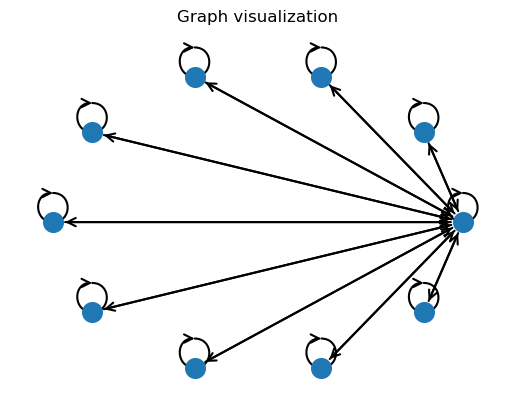

In [77]:
pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=200)

nx.draw_networkx_edges(
    G,
    pos,
    arrowstyle="->",
    arrowsize=15,
    width=1.5,
)

plt.title("Graph visualization")
plt.axis("off")
plt.show()

In [78]:
# transition matrix

P = nx.to_numpy_array(G, dtype=float)
P = P / P.sum(axis=1, keepdims=True)
P = P.T
P

array([[0.1, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.5],
       [0.1, 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. ],
       [0.1, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5]])

In [79]:
evals, evecs = np.linalg.eig(P)
idx = np.argmin(np.abs(evals - 1.0)) # index of 1-eigenvalue
v = evecs[:, idx].real
v = v / v.sum()
print(f"Ergodic density: {v}")

Ergodic density: [0.35714286 0.07142857 0.07142857 0.07142857 0.07142857 0.07142857
 0.07142857 0.07142857 0.07142857 0.07142857]


In [80]:
P @ v

array([0.35714286, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857])

## Task 3

In [81]:
k = 100
P_k = P
for i in range(k):
    P_k = P_k @ P
P_k

array([[0.35714286, 0.35714286, 0.35714286, 0.35714286, 0.35714286,
        0.35714286, 0.35714286, 0.35714286, 0.35714286, 0.35714286],
       [0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
        0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
       [0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
        0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
       [0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
        0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
       [0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
        0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
       [0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
        0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
       [0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
        0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857],
       [0.07142857, 0.07142857, 0.0714285

In [82]:
# column values should be the same
c0 = P_k[:, 0]
print(np.allclose(P_k - c0[:, None], 0, atol=1e-10)) # all columns are the same
print(f"Ergodic density: {c0}")

True
Ergodic density: [0.35714286 0.07142857 0.07142857 0.07142857 0.07142857 0.07142857
 0.07142857 0.07142857 0.07142857 0.07142857]


In [83]:
np.all(c0 - v < 1e-10) # the same results for both methods

True

In [84]:
P @ c0

array([0.35714286, 0.07142857, 0.07142857, 0.07142857, 0.07142857,
       0.07142857, 0.07142857, 0.07142857, 0.07142857, 0.07142857])

## Task 5

In [85]:
# implement PageRank and run on a net

def page_rank(P, alpha=1e-3, steps=10, v=None):
    n = P.shape[0]
    
    # initial ranks
    if v is None:
        v = np.ones(n) / n
    
    # imputing zero columns
    zero_cols = np.all(P == 0, axis=0)
    
    # power method
    for i in range(steps):
        v = alpha * P @ v + 1/n * (alpha * zero_cols @ v + (1 - alpha)) * np.ones(n)
        v = v / v.sum()
        
    return v

In [86]:
# imputing two randomly selected 0 columns
zero_columns = np.random.choice(10, 2)
P[:, zero_columns] = 0

In [87]:
P

array([[0. , 0.5, 0.5, 0.5, 0.5, 0.5, 0. , 0.5, 0.5, 0.5],
       [0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. , 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5, 0. ],
       [0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0. , 0.5]])

In [88]:
r = page_rank(P, steps=100)
r

array([0.1003199 , 0.09997001, 0.09997001, 0.09997001, 0.09997001,
       0.09997001, 0.09992002, 0.09997001, 0.09997001, 0.09997001])

In [89]:
np.linalg.norm(r - v) # difference from the eigenvalue

0.2707151665189206